# Теория вероятности, повышенный уровень


In [2]:
from math import pi, sqrt
from itertools import product
from matplotlib.patches import Circle, Rectangle
from numpy.random import uniform
import matplotlib.pyplot as plt
import numpy as np

### Тема 1. Моделирование геометрической вероятности
> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.
* Возьмём круг, площадь которого в k раз меньше площади стены: $$S_{\text{круга}} = \frac{1}{k}S_{\text{стены}}$$
Благоприятный исход - попадание в круг, поэтому: $$P(A) =\frac{S_{\text{круга}}}{S_{\text{стены}}}$$
Следовательно: $$P(A) =\frac{\frac{S_{\text{стены}}}{k}}{S_{\text{стены}}}= \frac{1}{k}$$
Таким образом, в среднем доля попадания дротиков при k = 2 равна: $$\boxed{P(A) = \frac{1}{2} = 0{,}5}$$


25.066282746310005


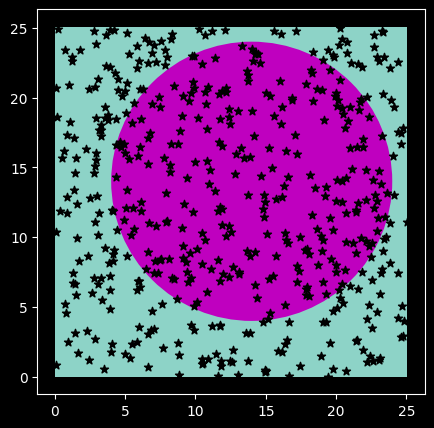

В круг попало 254 из 500 дротиков. Доля попавших составила 0.5080. В среднем доля попадания дротиков: 0.5000


In [3]:
x0, y0, R = 14, 14, 10
count, k = 500, 2
side = sqrt(k * pi * R ** 2)
print(side)
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(Rectangle((0, 0), side, side))
ax.add_patch(Circle((x0, y0), R, facecolor='m'))

X = uniform(0, side, count)
Y = uniform(0, side, count)
plt.scatter(X, Y, marker='*', c='black')

inside = len([d for d in (X-x0)**2 + (Y - y0)**2 if d <= R**2])
prob = inside / count

plt.show()
print(f"В круг попало {inside} из {count} дротиков. Доля попавших составила {prob:.4f}. В среднем доля попадания дротиков: {1 / k:.4f}")

### Тема 2. Моделирование связи частотного и классического определения вероятности
>Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.

* Кубики симметричны, поэтому все пары равновозможны: $$n = 6 \cdot 6 = 36$$
Событию $A$ — сумма очков равна 7 — благоприятствуют исходы $(1,6), (2,5), (3,4), (4,3), (5,2), (6,1)$, то есть $m = 6$.
По классическому определению вероятности: $$P(A) = \frac{m}{n} = \frac{6}{36} = \boxed{\frac{1}{6} \approx 0{,}1667}$$
Частотная вероятность события $A$ — доля опытов, в которых оно произошло: $$P^*(A) = \frac{m_N}{N}$$
Из моделирования видно, что при увеличении числа опытов частотная вероятность приближается к классической. Классическая вероятность — это предельный случай бесконечного числа экспериментов.

In [ ]:
target = 7
rng = np.random.default_rng(42)
ls = list(product('123456', repeat=2))
prob = {}
for pair in ls:
    sum_ = sum(list(map(int, pair)))
    prob[sum_] = prob.get(sum_, 0) + 1
N = len(ls)
prob = {sum_: count / N for sum_, count in prob.items()}
P_theor, P_freq = prob[target], {}
for n in 100, 1000, 10000, 100000, 1000000:
    s = rng.integers(1, 7, n) + rng.integers(1, 7, n)
    m = int(np.sum(s == target))
    P_freq[n] = m / n
print(f"Теоретическая вероятность: {P_theor:.4f}")
print("Частотная вероятность:")
for n, p in P_freq.items():
    print(f"n = {n} -> p = {p:.4f}")
n_max = 100000
s = rng.integers(1, 7, n_max) + rng.integers(1, 7, n_max)
freq = np.cumsum(s == target) / np.arange(1, n_max + 1)
fig, ax = plt.subplots(figsize=(9, 5))
plt.plot(np.arange(1, n_max + 1), freq, lw=0.8, c='navy', label='частотная вероятность')
plt.axhline(P_theor, c='red', ls='--', label=f'классическая вероятность = {P_theor:.4f}')
plt.xscale('log')
plt.ylim(0, 0.5)
plt.xlabel('число опытов N')
plt.ylabel('P(A)')
plt.title(f'Стремление частотной вероятности к классической (сумма = {target})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()